In [3]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib, pickle
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')
from IPython.display import clear_output

from python import forces, integrators, random_matrix, simulate, densities, plotters
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters);

---

In [5]:
# Test the new MAIMLA implementation.
N = 100; dt = 1/N; beta = 2.0; T = 10.0;
M = 1000; potential_name = "quartic"; total_steps = int(T/dt)

init = random_matrix.init_quartic_eigenvalues(M, N)
maimla_pipe = simulate.make_maimla_pipeline(N, dt, potential_name, beta)
trajectory = simulate.simulate_dbm(init, total_steps, maimla_pipe)

config = {
    "burn_in": int(0.5/dt), # Init might not be fully burn
    "snapshot_interval": 5,
    "track_accepts": True,
    "track_newton_info": True # Also includes CG iterations and line search rejects.
}

info = simulate.analyse_trajectory(trajectory, total_steps, **config)

In [8]:
info.keys()

dict_keys(['snapshots', 'accepts', 'newton_iters', 'mean_cg_iters', 'line_search_rejects'])

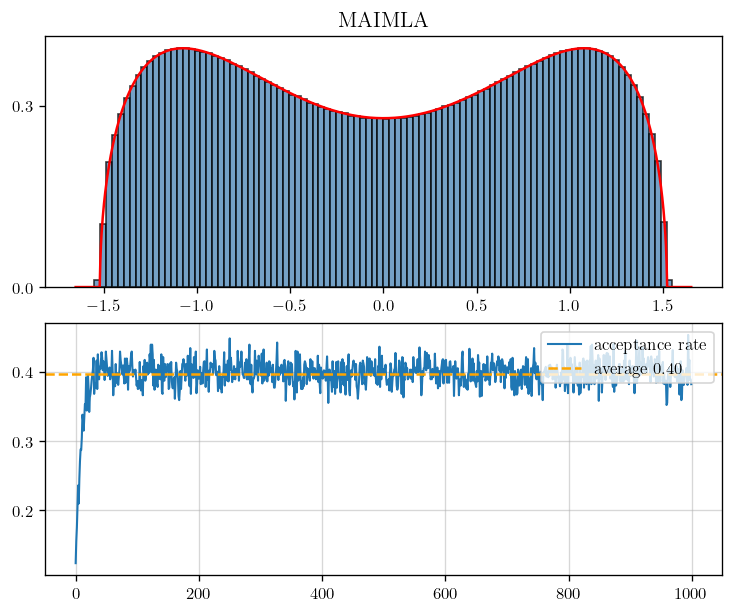

Mean Newton iterations: 5.41
Mean CG iterations: 8.46


In [13]:
fig, axes = plt.subplots(2, 1, figsize = (6, 5))
ax, ax2 = axes

plotters.plot_hist(ax, info["snapshots"], num_bins = 100, potential_name = potential_name)
plotters.plot_accepts(ax2, info["accepts"])

ax.grid(False)
ax.set_title(f"MAIMLA")

plt.show()

print(f"Mean Newton iterations: {info["newton_iters"].mean():.2f}")
print(f"Mean CG iterations: {info["mean_cg_iters"].mean():.2f}")

---
---
---

MAIMLA but scale $N$ and see how $dt$ needs to behave (heuristically).

For $N = 300$, running from equilibrium until $T = 1$,
- and $1/N$, avg. accept $0.02$ and mean crossing rejects $0.54$;
    - for MALA avg. accept $0.0$ with mean crossing rejects $1.0$.
- and $1/2N$, avg. accept $0.29$ and mean crossing rejects $0.25$;
    - for MALA avg. accept $0.0$ with mean crossing rejects $0.74$.
- and $1/4N$, avg. accept $0.55$ and mean crossing rejects $0.10$;
    - for MALA avg. accept $0.05$ with mean crossing rejects $0.54$.

For $N = 500$, same experiment but until $T = 0.5$,
- and $1/N$, avg. accept $0.0$ with mean crossing rejects $0.74$;
    - for MALA avg. accept $0.0$ with mean crossing rejects $1.0$.
- and $1/2N$, avg. accept $0.10$ with mean crossing rejects $0.33$;
    - for MALA avg. accept $0.0$ with mean crossing rejects $0.86$.
- and $1/4N$, av.g accept $0.41$ with mean crossing rejects $0.16$;
    - for MALA, avg. accecpt $0.01$ with mean crossing rejects $0.71$.

For $N = 1000$, same experiment but until $T = 0.2$,
- and $1/4N$, avg. accept $0.22$ with mean crossing rejects $0.28$;
    - for MALA, avg. accept $0.0$ wth mean crossing rejects $0.83$.

---

In [52]:
def print_info(info, title = None):
    fig, axes = plt.subplots(2, 1, figsize = (6, 5))
    ax1, ax2 = axes

    plotters.plot_hist(ax1, info["snapshots"], num_bins = 100, potential_name = "quartic")
    plotters.plot_accepts(ax2, info["accepts"][100:])

    ax1.grid(False)
    if (title):
        ax1.set_title(title)

    plt.show()
    
    if ("newton_iters" in info):
        print(f"Mean Newton iterations: {info["newton_iters"].mean():.2f}")
        print(f"Mean CG iterations: {info["mean_cg_iters"].mean():.2f}")
    
    print(f"Mean rejects by crossing: {info["cross_rejects"].mean():.2f}")


In [49]:
# Same init for both MAIMLA and MALA.
M = 20; N = 1000
init = random_matrix.init_quartic_eigenvalues(M, N, dt = 0.05)

In [50]:
T = 0.2; potential_name = "quartic"; beta = 2.0;
dt = 1/(4*N); total_steps = int(T/dt)

maimla_pipe = simulate.make_maimla_pipeline(N, dt, potential_name, beta)
maimla_trajectory = simulate.simulate_dbm(init, total_steps, maimla_pipe)
maimla_config = {"burn_in": 0, "snapshot_interval": 5, "track_accepts": True, "track_newton_info": True}

mala_pipe = simulate.make_mala_pipeline(N, dt, potential_name, beta)
mala_trajectory = simulate.simulate_dbm(init, total_steps, mala_pipe)
mala_config = {"burn_in": 0, "snapshot_interval": 5, "track_accepts": True}

maimla_info = simulate.analyse_trajectory(maimla_trajectory, total_steps, **maimla_config)
mala_info = simulate.analyse_trajectory(mala_trajectory, total_steps, **mala_config)

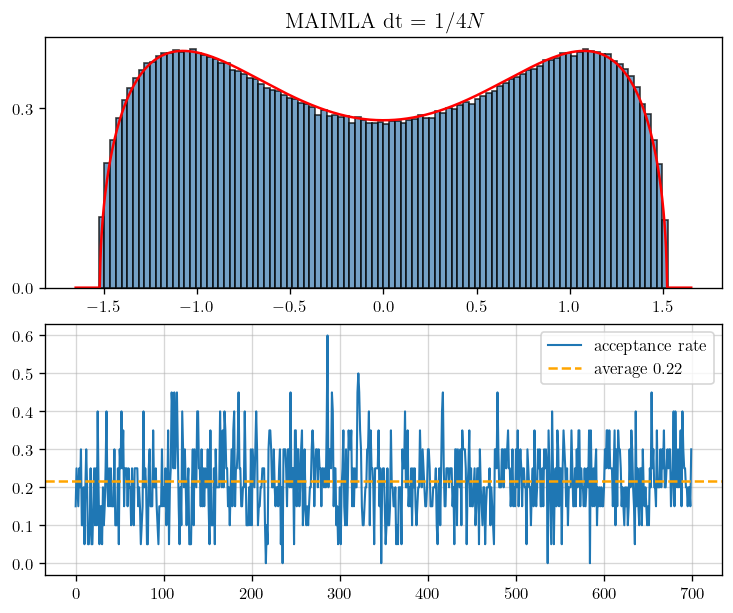

Mean Newton iterations: 5.54
Mean CG iterations: 8.28
Mean rejects by crossing: 0.28


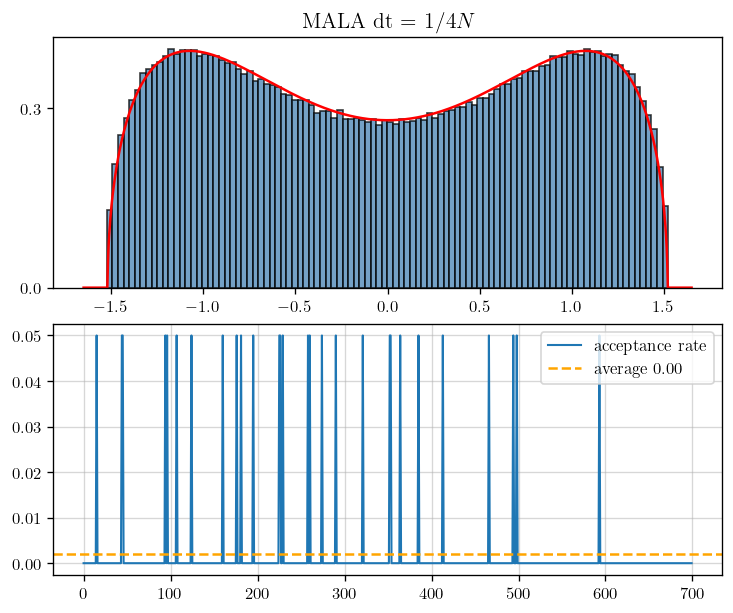

Mean rejects by crossing: 0.83


In [53]:
title = r"MAIMLA dt = $1/4N$"
print_info(maimla_info, title)

title2 = r"MALA dt = $1/4N$"
print_info(mala_info, title2)